In [1]:
import xarray as xr
import numpy as np
import glob
import pandas as pd
import pygmt
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.interpolate import RBFInterpolator
from scipy.ndimage import gaussian_filter
#from geopy.distance import geodesic
#import src.processing as cl
import src.plotting as pl

In [2]:
#################################################
# --- CONFIGURATION ---
#to match the parameters of the tomographic inversion
#if needed, ajust the grid size and the number of points
min_max_dep=[-5, 45] # depth in km
n_rtp=[101, 101, 151]
#n_rtp_less=[61, 61, 101]
region_tomo=[-12, -2, 50, 56]
region_ireland=[-11, -5.5, 51, 55.5]
region = region_ireland

pygmt.config(FONT="14p,Palatino-Roman", 
             FONT_ANNOT_PRIMARY="14p,Palatino-Roman",
             FONT_ANNOT_SECONDARY="14p,Palatino-Roman",
             FONT_LABEL="16p,Times-Roman",
             IO_SEGMENT_MARKER="<<<",
             MAP_FRAME_TYPE = 'plain',
             FORMAT_GEO_MAP = 'D')

folder = "/home/bmelo/Quarry/Eire-velocity_models/out_models/"
profile_files = sorted(glob.glob(folder + "*/*_vp.nc"))  # your .nc files
lines = pd.read_csv("/home/bmelo/Quarry/Eire-velocity_models/line_coords")

In [3]:
# --- GATHER ALL PROFILE POINTS ---
all_points = []
all_values = []

for f in profile_files:
    pf = xr.open_dataset(f)
    print(f"Processing file: {f}")

    lon = pf["lon"].values  # shape: (x,)
    lat = pf["lat"].values  # shape: (x,)
    z = pf["z"].values      # shape: (z,)
    vp = pf["vp"].values    # shape: (z, x)
    
   # --- Filter out negative depths ---
    valid_idx = z >= 0
    z = z[valid_idx]
    vp = vp[valid_idx, :]       # shape: (z, x)
    
    for xi in range(vp.shape[1]):
        col = vp[:, xi]
        valid = np.isfinite(col)
        if not np.any(valid):
            continue
        last_idx = np.where(valid)[0][-1]
        last_val = col[last_idx]
        if last_idx < len(col) - 1:
            col[last_idx+1:] = last_val
        vp[:, xi] = col
    
    # --- Generate coordinate grids to match vp ---
    lon2d, z2d = np.meshgrid(lon, z)  # shape: (z, x)
    lat2d, _   = np.meshgrid(lat, z)  # shape: (z, x)

    # Stack into (N, 3) coordinates and flatten vp values
    all_points.append(np.column_stack([z2d.ravel(), lat2d.ravel(), lon2d.ravel()]))  # (z, lat, lon)
    all_values.append(vp.ravel())

# --- COMBINE ALL PROFILES ---
all_points = np.vstack(all_points)         # shape: (N_points, 3)
all_values = np.hstack(all_values)   # shape: (N,)

# --- DEFINE TARGET GRID ---
lon_min, lon_max = region[0], region[1]
lat_min, lat_max = region[2], region[3]
z_min, z_max = min_max_dep

Ngrid = n_rtp
lon_grid = np.linspace(lon_min, lon_max, Ngrid[0])
lat_grid = np.linspace(lat_min, lat_max, Ngrid[1])
z_grid   = np.linspace(z_min, z_max, Ngrid[2])

lons = all_points[:, 2]
lats = all_points[:, 1]

# Generate a mask: 1 for land, NaN for ocean
print("Creating grid with land mask...")
land_mask = pygmt.grdlandmask(
    region=region,
    spacing=[lon_grid[1] - lon_grid[0], lat_grid[1] - lat_grid[0]],
    maskvalues=[0, np.nan, np.nan, np.nan, np.nan],
    resolution="h",
    registration="gridline"
)

mask_values = land_mask.interp(
    lon=xr.DataArray(lons, dims="points"),
    lat=xr.DataArray(lats, dims="points"),
    method="nearest"
).values

# Final mask: True for land, False for ocean
is_land = np.isnan(mask_values)

# Apply to your data
land_points = all_points[is_land]
land_values = all_values[is_land]

Processing file: /home/bmelo/Quarry/Eire-velocity_models/out_models/COOLE/COOLE1_vp.nc
Processing file: /home/bmelo/Quarry/Eire-velocity_models/out_models/ICSSP/ICSSP_vp.nc
Processing file: /home/bmelo/Quarry/Eire-velocity_models/out_models/LEGS/LEGSA_vp.nc
Processing file: /home/bmelo/Quarry/Eire-velocity_models/out_models/LEGS/LEGSB_vp.nc
Processing file: /home/bmelo/Quarry/Eire-velocity_models/out_models/LEGS/LEGSC_vp.nc
Processing file: /home/bmelo/Quarry/Eire-velocity_models/out_models/VARNET/VARNETA_vp.nc
Processing file: /home/bmelo/Quarry/Eire-velocity_models/out_models/VARNET/VARNETB_vp.nc
Creating grid with land mask...


In [7]:
# 1. Create 3D grid
Z, LAT, LON = np.meshgrid(z_grid, lat_grid, lon_grid, indexing="ij")  # shape: (z, lat, lon)
interp_targets = np.column_stack([Z.ravel(), LAT.ravel(), LON.ravel()])  # shape: (N_gridpoints, 3)

# 2. Interpolate using RBF
print("Interpolating with RBF... Normal to take a while, please be patient.")
rbf = RBFInterpolator(
    land_points, land_values,
    kernel="linear",     # or "thin_plate_spline", "multiquadric"
    neighbors=40,         # adjust for performance vs. accuracy
    smoothing=2,              # helps with robustness
    #degree=None,                # polynomial degree
    epsilon=1
)

print("Interpolation complete. Reshaping results...")
vp_3d = rbf(interp_targets).reshape(Z.shape)

# 3. Extrapolate and smooth
vp_smooth = gaussian_filter(vp_3d, sigma=(5, 5, 5))  # (z, lat, lon)

# 4. Interpolate land mask to your lat/lon grid
lon2d, lat2d = np.meshgrid(lon_grid, lat_grid)
land_mask_interp = land_mask.interp(
    lon=xr.DataArray(lon2d, dims=["y", "x"]),
    lat=xr.DataArray(lat2d, dims=["y", "x"]),
    method="nearest"
)
land_mask_2d = np.isnan(land_mask_interp.values)

# 6. Broadcast to 3D
land_mask_3d = np.broadcast_to(land_mask_2d, vp_smooth.shape[1:])

# 7. Apply land mask
vp_masked = np.where(land_mask_3d, vp_smooth, np.nan)

# --- SAVE TO NETCDF ---
ds_3d = xr.Dataset(
    {"vp": (("z", "lat", "lon"), vp_masked)},
    coords={"z": z_grid, "lat": lat_grid, "lon": lon_grid},
    attrs={"description": "3D Vp model (RBF interpolated and smoothed)"}
)
ds_3d.to_netcdf(folder + "interpolated/vp_3d_rbf.nc")
print("Saved 3D velocity model to vp_3d_rbf.nc.")

Interpolating with RBF... Normal to take a while, please be patient.
Saved 3D velocity model to vp_3d_rbf.nc.


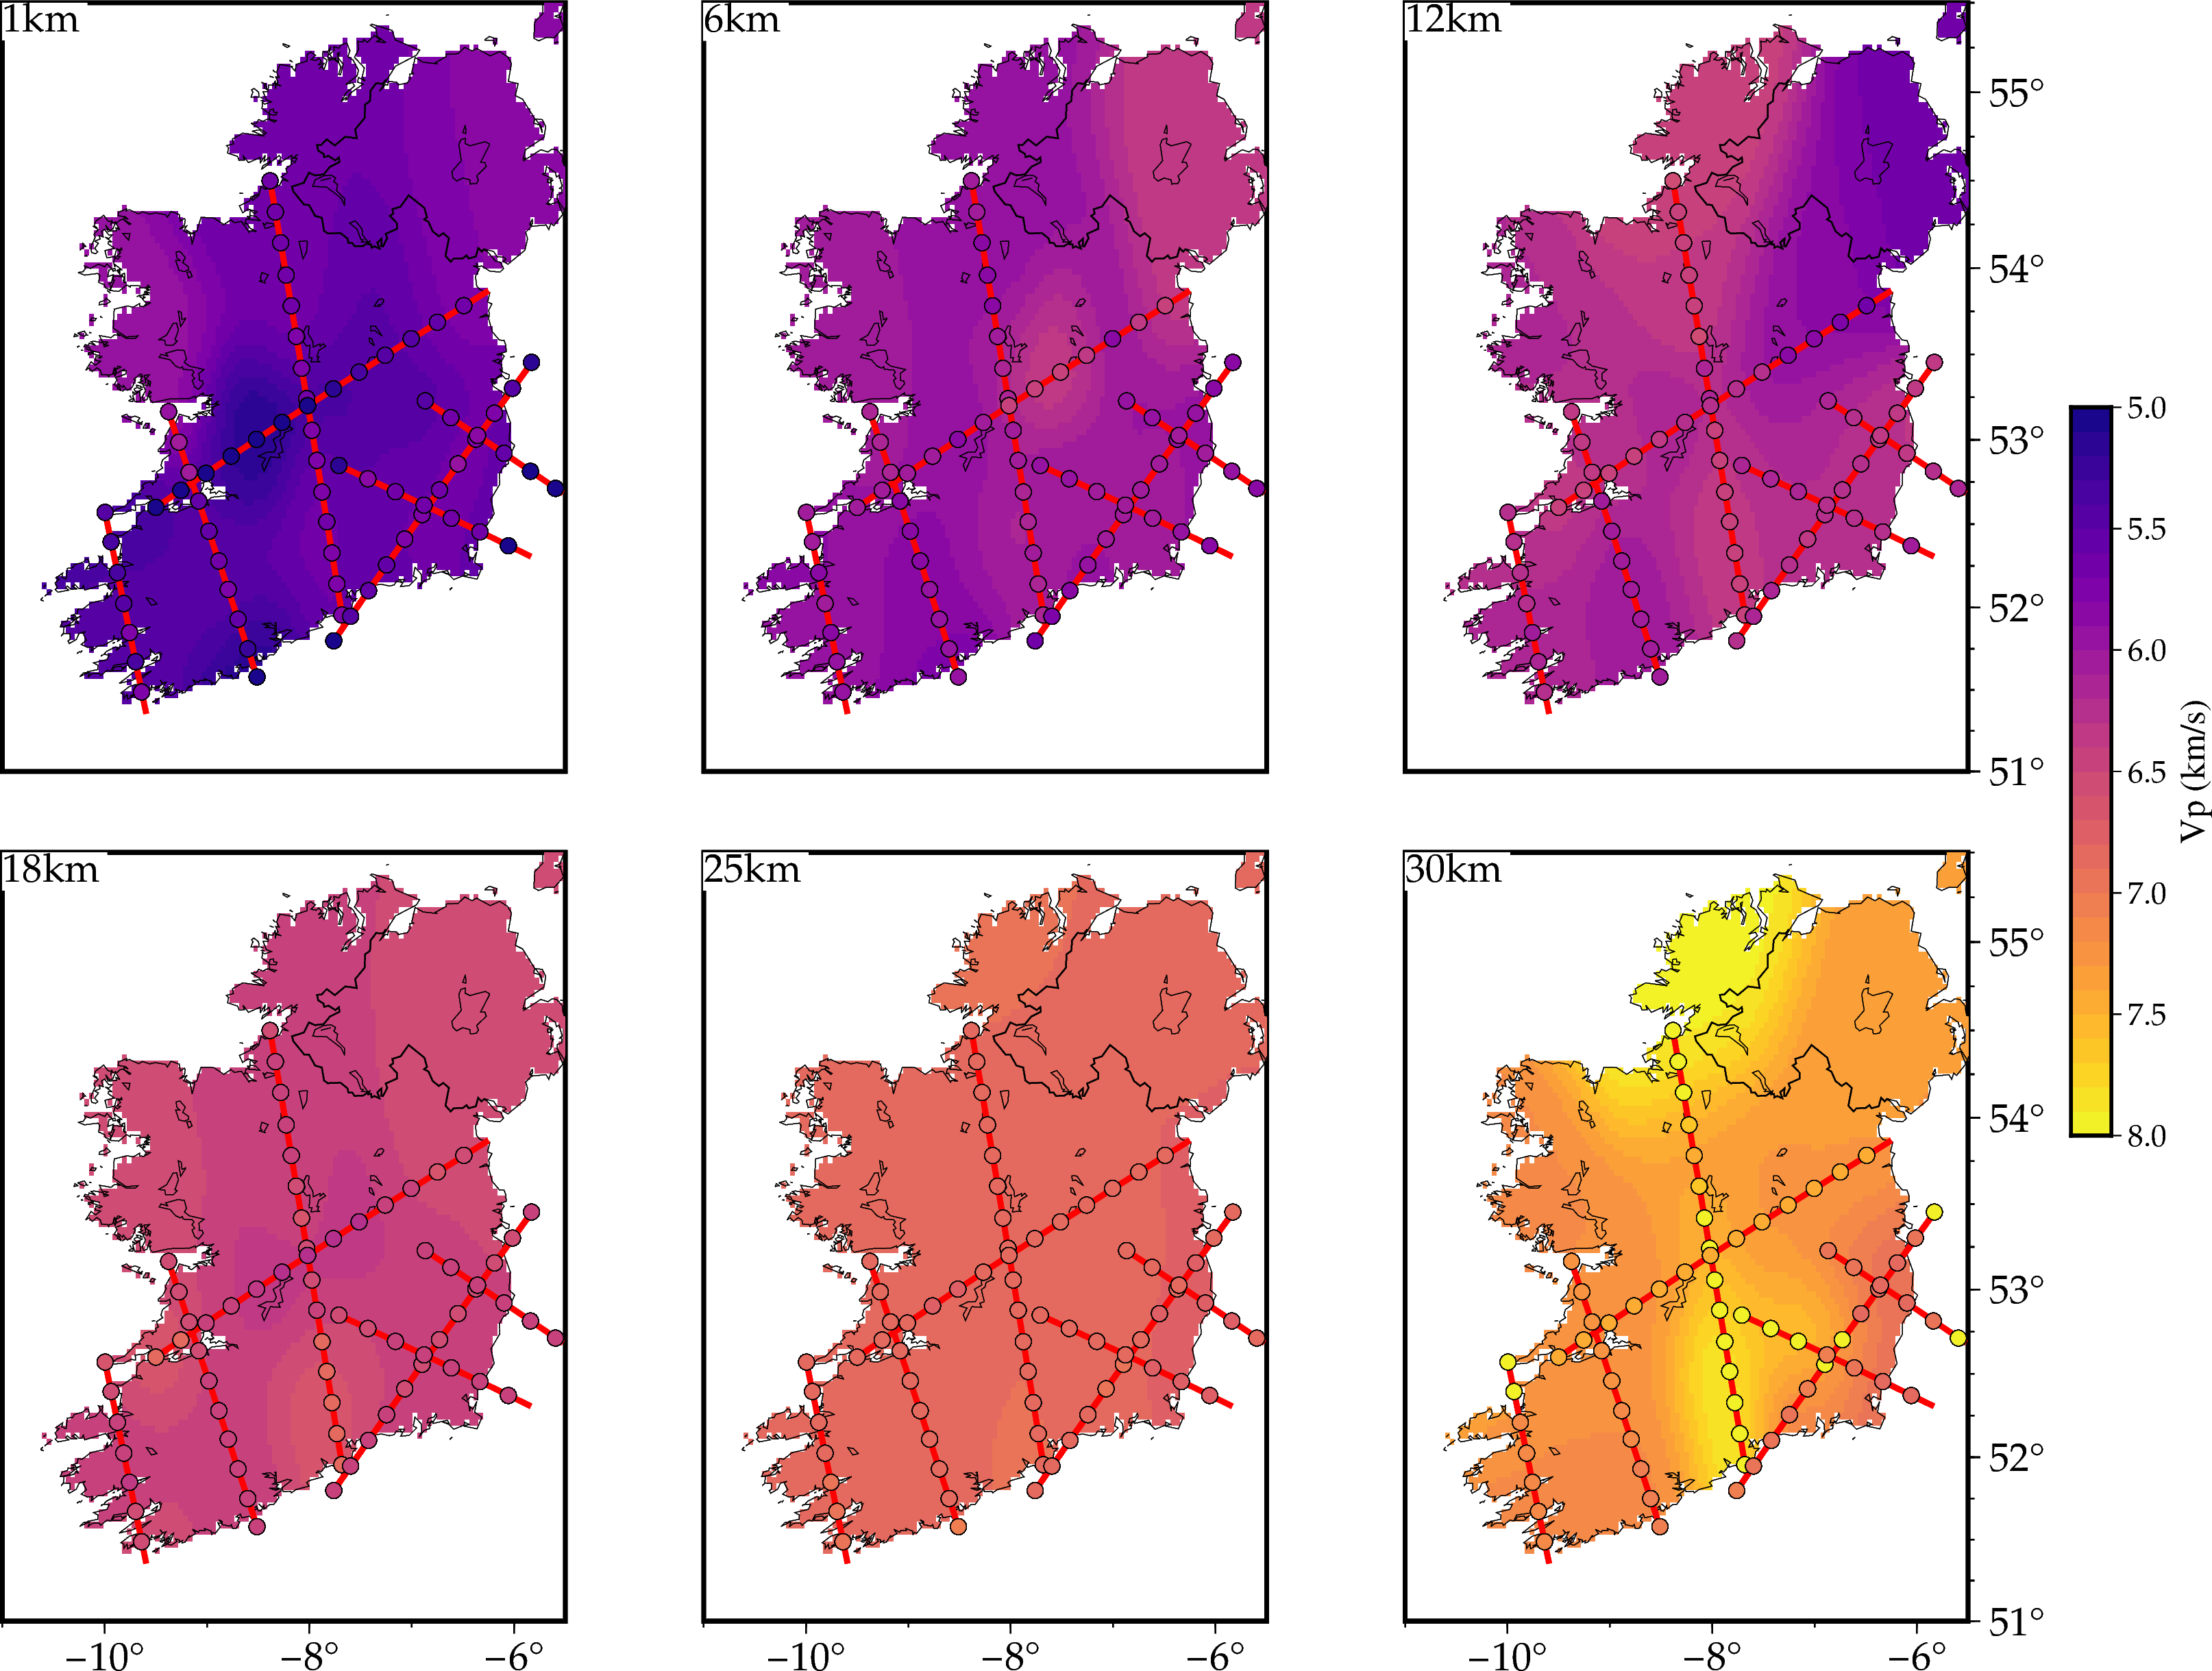

<Figure size 640x480 with 0 Axes>

In [13]:
ds= xr.open_dataset(folder + "interpolated/vp_3d_rbf.nc")
#visualize interpolation
fig = pygmt.Figure()

# Define the region and projection
depth = [1, 6, 12, 18, 25, 30]

# Create the subplot layout
rows=2
with fig.subplot(
    nrows=rows,
    ncols=len(depth)/rows,
    figsize=("25c", "20c"),
    frame="lrbt",
    margins="0.5/0.5c",
    sharex="b",
    sharey="r"
    ):
    
    for i, dep in enumerate(depth):
        with fig.set_panel(panel=i):
            pl.plot_velocity_map(fig, ds, region, dep, series=[5, 8, 0.1])
            pl.plot_scatter(fig, profile_files, lines, dep, 0.5, 20)
            if i == len(depth) - 1:
                fig.colorbar(
                    frame=["a0.5","x+lVp (km/s)"],
                    position="JBC+o5c/-15c+w-9c/0.5c+v",
                    scale=1
                    #reverse=True,
                )
fig.show()
plt.savefig(folder + "interpolated/vp_3D.png", dpi=300, bbox_inches='tight')

In [5]:
print("Calculate 1D velocity average...")

#3D velocity average
ds = xr.open_dataset(folder + "interpolated/vp_3d_rbf.nc")
vp = ds["vp"].values    # (z, lat, lon)
lat = ds["lat"].values
lon = ds["lon"].values
z   = ds["z"].values
vp_1d = np.nanmean(vp, axis=(1, 2))  # shape: (z,)

#velocity average between all profiles (for reference)
profile_averages = []
all_depths = []

for f in profile_files:
    ds_2d = xr.open_dataset(f)
    tag=f.split("/")[-1].split("_")[0]  # Extract tag from filename
    z_2d = ds_2d["z"].values
    vp_2d = ds_2d["vp"].values  # shape: (z, x)
    valid_idx = z_2d >= 0  # Filter out negative depths
    z_2d = z_2d[valid_idx]
    vp_2d = vp_2d[valid_idx, :]
    vp_2d_avg = np.nanmean(vp_2d, axis=1)  # Average over horizontal axis
    profile_averages.append((z_2d, vp_2d_avg, tag))
    all_depths.append(z_2d)

# Interpolate all profile averages onto the common grid
vp_interp_all = []
dz = 0.1
z_common = np.arange(min_max_dep[0], min_max_dep[1] + dz, dz)
for z_2d, vp_2d, _ in profile_averages:
    f_interp = interp1d(z_2d, vp_2d, bounds_error=False, fill_value=np.nan)
    vp_interp_all.append(f_interp(z_common))
vp_interp_all = np.vstack(vp_interp_all)  # shape: (n_profiles, n_depths
vp_mean_all = np.nanmean(vp_interp_all, axis=0)  # shape: (n_depths,)

print("Saving 1D velocity model to ASCII file...")
Ngrid = n_rtp
# Create custom ASCII file in the format lon, lat, dep, velocity
with open(folder + "interpolated/vp_1d_full.txt", "w") as f:
    for k in range(Ngrid[2]):
        for j in range(Ngrid[1]):
            for i in range(Ngrid[0]):
                if not np.isnan(vp_1d[k]):  # Only include non-NaN values
                    f.write(f"{lon[i]} {lat[j]} {z[k]} {vp_1d[k]}\n")
                    
with open(folder + "interpolated/vp_1d_simple.txt", "w") as f:
    for k in range(Ngrid[2]):
        if not np.isnan(vp_1d[k]):
            f.write(f"{z[k]} {vp_1d[k]}\n")


Calculate 1D velocity average...


/tmp/ipykernel_2994031/1170806801.py:23: RuntimeWarning: Mean of empty slice
  vp_2d_avg = np.nanmean(vp_2d, axis=1)  # Average over horizontal axis
/tmp/ipykernel_2994031/1170806801.py:35: RuntimeWarning: Mean of empty slice
  vp_mean_all = np.nanmean(vp_interp_all, axis=0)  # shape: (n_depths,)


Saving 1D velocity model to ASCII file...


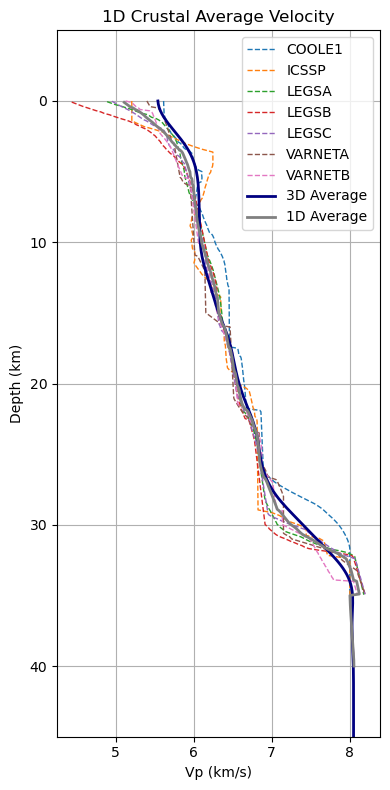

<Figure size 640x480 with 0 Axes>

In [7]:
# --- Plot the result ---
plt.figure(figsize=(4, 8))
for i, (z_2d, vp_2d_avg, tag) in enumerate(profile_averages):
    plt.plot(vp_2d_avg, z_2d, linestyle='--' ,lw=1, label=tag)
plt.plot(vp_1d, z, color='navy', lw=2, label="3D Average")
plt.plot(vp_mean_all, z_common, color='gray', lw=2, label="1D Average")
plt.gca().invert_yaxis()
plt.xlabel("Vp (km/s)")
plt.ylabel("Depth (km)")
plt.ylim(45,-5)
plt.grid(True)
plt.title("1D Crustal Average Velocity")
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig(folder + "interpolated/vp_1D.png", dpi=300)

From here on it's still in progress...

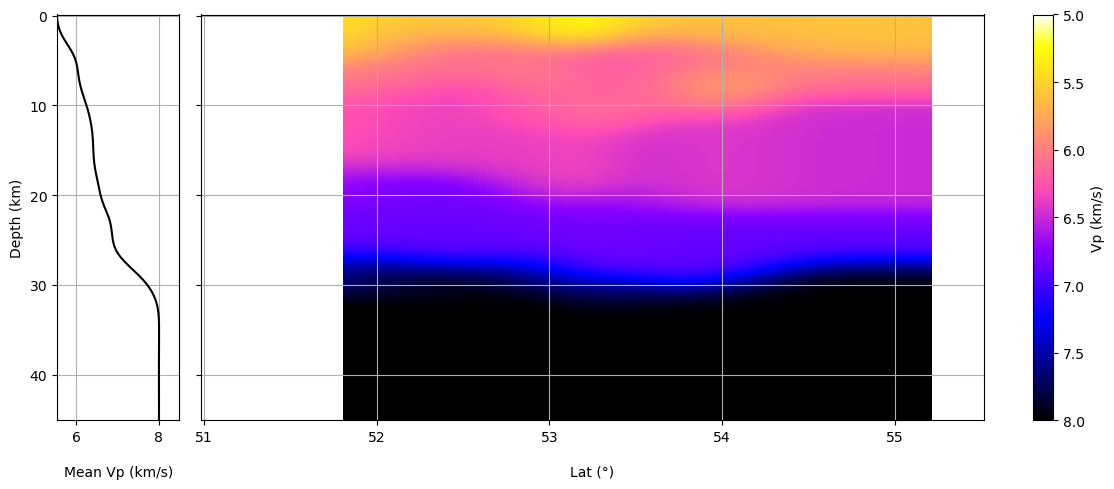

In [14]:
def plot_velocity_section(ncfile, mode="lon", value=None, cmap="jet", title=None):
    """
    Plot a vertical velocity section at constant latitude or longitude.

    Parameters:
        ncfile (str): Path to NetCDF file with 'vp(z, lat, lon)'.
        mode (str): 'lon' (default) for lat–depth section, or 'lat' for lon–depth section.
        value (float): The lon or lat value where to slice.
        cmap (str): GMT colormap name.
        title (str): Optional title for the plot.

    Example:
        plot_velocity_section("vp_3d_rbf.nc", mode="lon", value=-9.0)
    """
    #ds = xr.open_dataset(ncfile)
    ds=ncfile
    vp = ds["vp"].transpose("z", "lat", "lon").values
    lat = ds["lat"].values
    lon = ds["lon"].values
    z = ds["z"].values

    # Determine slice
    if mode == "lon":
        if value is None:
            value = lon[len(lon)//2]
        ix = np.abs(lon - value).argmin()
        vp_slice = vp[:, :, ix]  # shape: (z, lat)
        coords = {"z": z, "lat": lat}
        dims = ("z", "lat")
        region = [lat.min(), lat.max(), z.min(), z.max()]
        xlabel = "Latitude"
    elif mode == "lat":
        print("lat")
        if value is None:
            value = lat[len(lat)//2]
        iy = np.abs(lat - value).argmin()
        vp_slice = vp[:, iy, :]  # shape: (z, lon)
        coords = {"z": z, "lon": lon}
        dims = ("z", "lon")
        region = [lon.min(), lon.max(), z.min(), z.max()]
        xlabel = "Longitude"
    else:
        raise ValueError("mode must be 'lon' or 'lat'")

    # Temporary NetCDF for PyGMT
    section_ds = xr.Dataset({"vp": (dims, vp_slice)}, coords=coords)
    section_file = "interpolated/vp_section.nc"
    section_ds.to_netcdf(folder + section_file)
    
    # Compute 1D velocity average at each depth
    vp_mean = np.nanmean(section_ds["vp"].values, axis=1)  # mean along the horizontal axis (lat or lon)

    # --- PLOTTING ---
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 8]}, sharey=True)
    # Add 1D velocity average on right
    ax1.plot(vp_mean, section_ds["z"].values, color="black", linewidth=1.5, label="Mean Vp")
    ax2.invert_yaxis()
    ax1.set_ylabel("Depth (km)")
    ax1.set_xlim(min(vp_mean), 8.5)  # Adjust if needed
    ax1.set_xlabel("Mean Vp (km/s)", labelpad=15)
    ax1.grid(True)
    
    # Cross-section plot (2D)
    img = ax2.pcolormesh(section_ds["lat"] if "lat" in section_ds.dims else section_ds["lon"],
                         section_ds["z"],
                         section_ds["vp"],
                         shading="auto",
                         cmap='gnuplot2_r',
                         vmin=5.0, vmax=8.0)
    ax2.set_xlabel("Lat (°)" if "lat" in section_ds.dims else "Lon (°)", labelpad=15)
    ax2.grid(True)
    # Colorbar (attached to 2D plot)
    cbar = plt.colorbar(img, ax=ax2, label="Vp (km/s)")
    cbar.ax.invert_yaxis()

    plt.tight_layout()
    plt.show()
    
# --- Choose a fixed longitude for the section ---
#vp_grd = "/home/bmelo/bin/SeisBlast/1D_velocity/3D-model/vp_3d_rbf.nc"
ds= xr.open_dataset(folder + "interpolated/vp_3d_rbf.nc")
plot_velocity_section(ds, mode="lon", value=-8)

In [ ]:
#Attempt on saving the 3D model to the TOMOAtt format
# ds = ds_3d  # drop empty depth levels
# # --- Load NetCDF velocity model ---
# #ds = xr.open_dataset("vp_3d_rbf.nc")  # adjust path
# vp = ds["vp"].transpose("z", "lat", "lon").values
# lat = ds["lat"].values
# lon = ds["lon"].values
# z   = ds["z"].values

# # --- Create a 3D grid for the land mask ---
# # Define Ngrid based on the shapes of lon, lat, and z
# Ngrid = n_rtp

# # Create custom ASCII file in the format lon, lat, dep, velocity
# with open(folder + "vp_3d_full.txt", "w") as f:
#     for k in range(Ngrid[2]):
#         for j in range(Ngrid[1]):
#             for i in range(Ngrid[0]):
#                 if not np.isnan(vp[k, j, i]):  # Only include non-NaN values
#                     f.write(f"{lon[i]} {lat[j]} {z[k]} {vp[k, j, i]}\n")
